In [1]:
import os
import numpy as np
import sympy as sp
import pylbo as pb
import pylbo.gimli as gl
import matplotlib.pyplot as plt

## Define equilibrium

In [2]:
var = gl.Variables()
B2field = var.B2c * sp.tanh(var.x / var.alpha)
B3field = 0
v2field = 0
v3field = 0
density = var.rhoc
temperature = var.Tc - (B2field**2 + B3field**2) / (2.0 * density)
grid = var.p1 - (var.p1 - var.p3) * sp.exp(-(var.x - var.p2)**2 / (2 * var.p4))

In [3]:
equil = gl.Equilibrium(var, density, v2field, v3field, temperature, B02=B2field, B03=B3field, legolas_grid_spacing=grid)

## Create Legolas files

In [4]:
if (not os.path.exists("./legolas/")):
    os.system("mkdir -p ./legolas/")

legolas_config = {
    "geometry": "Cartesian",
    "x_start": -15,
    "x_end": 15,
    "gridpoints": 100,
    "solver": "QR-cholesky",
    "symmetric_grid": True,
    "parameters": {
        "k2": 0.5,
        "k3": 0,
        "cte_rho0": 1,
        "cte_T0": 1,
        "cte_B02": 1,
        "alpha": 1,
        "p1": 0.75,
        "p2": 0,
        "p3": 0.001,
        "p4": 2.5,
    },
    "equilibrium_type": "user_defined",
    "boundary_type": "wall_weak",
    "physics_type": "mhd",
    "resistivity": True,
    "fixed_resistivity_value": 1e-3,
    "basename_datfile": "tearing",
    "output_folder": './output/',
    "write_derived_eigenfunctions": True,
    "show_results": False,
}
legolas = gl.Legolas(equil, legolas_config)
parfiles = legolas.parfile(loc="./legolas/")
legolas.user_module(loc="./legolas/")

2025-11-10 14:19:33,338 - |INFO    | parfiles generated and saved to /Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/legolas/parfiles


In the `legolas` folder, run
```
setuplegolas.py
buildlegolas.sh
```
to compile Legolas and
```
./legolas -i parfiles/legolas_config.par
```
to obtain the eigenmodes and corresponding perturbations, or set up a multirun to find the most unstable wavenumber:

In [5]:
os.chdir("./legolas")

output = f"./output/multirun"
if (not os.path.exists(output)):
    os.system("mkdir -p " + output)

nr_runs = 100
legolas_config["solver"] = "inverse-iteration"
legolas_config["sigma"] = -1e-12+0.1j
legolas_config["maxiter"] = 1000
legolas_config["tolerance"] = 1e-7
legolas_config["number_of_runs"] = nr_runs
legolas_config["parameters"]["k2"] = np.logspace(-2, 0, nr_runs)
legolas_config["write_eigenfunctions"] = False
legolas_config["write_derived_eigenfunctions"] = False
legolas_config["basename_datfile"] = ""
legolas_config["output_folder"] = output
legolas_config["logging_level"] = 0

parfiles = pb.generate_parfiles(parfile_dict=legolas_config)
pb.run_legolas(parfiles, nb_cpus=4, executable="legolas", remove_parfiles=True)

os.chdir("..")

2025-11-10 14:19:39,974 - |INFO    | parfiles generated and saved to /Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/legolas/parfiles
2025-11-10 14:19:39,978 - |INFO    | initialising runner, using executable /Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/legolas/legolas


running legolas [4 CPUS]: 100%|██████████| 100/100 [00:12<00:00,  8.31/s]

2025-11-10 14:19:52,026 - |INFO    | all runs completed
2025-11-10 14:19:52,032 - |INFO    | parfiles removed.


2025-11-10 14:19:54,391 - |INFO    | Legolas_version  : 2.2.1
2025-11-10 14:19:54,391 - |INFO    | files loaded     : 0001.dat --> 0100.dat
2025-11-10 14:19:54,391 - |INFO    | gridpoints       : 283
2025-11-10 14:19:54,392 - |INFO    | geometries       : Cartesian
2025-11-10 14:19:54,392 - |INFO    | equilibria       : user_defined
2025-11-10 14:19:54,392 - |INFO    | ---------------------------------------------------------------------------
Maximum at k2 = 0.2154


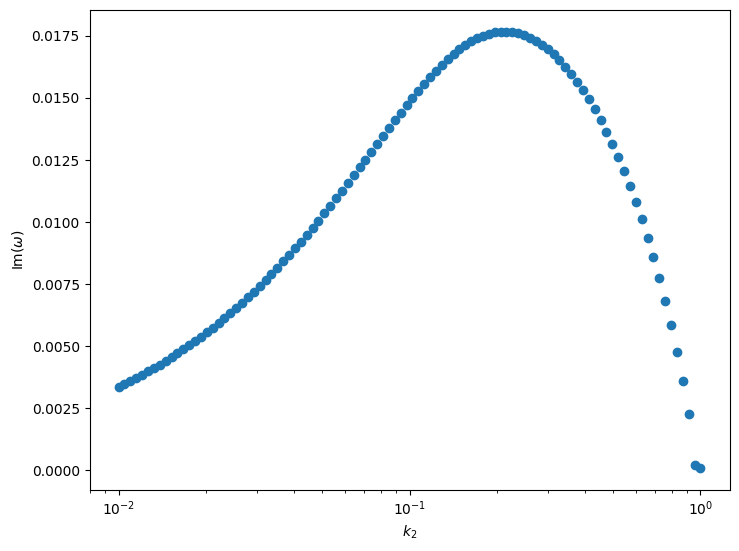

In [6]:
fig = plt.figure()
ax = fig.add_axes((1, 1, 1, 1))

folder = f"./legolas{output[1:]}/"
files = os.listdir(folder)
for ii in range(len(files)):
    files[ii] = folder + files[ii]
files.sort()

series = pb.load_series(files)
var = []
evs_i = []
for ds in series:
    param = ds.parameters["k2"]
    var.append(param)
    # Identify tearing mode
    evs = [x.imag for x in ds.eigenvalues if abs(x.real) < 1e-6]
    tm_imag = max(evs)
    evs_i.append(tm_imag)
    gridpts = ds.gridpoints

ax.plot(var, evs_i, "o", c="tab:blue")
ax.set_xscale("log")
ax.set_xlabel(r"$k_2$")
ax.set_ylabel(r"Im($\omega$)")

kmax = var[np.argmax(evs_i)]
print(f"Maximum at k2 = {round(kmax, 4)}")
plt.show()

In [7]:
legolas.config["parameters"]["k2"] = kmax
legolas.parfile(loc="./legolas/")
os.chdir("./legolas")
os.system("./legolas -i parfiles/legolas_config.par")
os.chdir("..")

2025-11-10 14:20:18,806 - |INFO    | parfiles generated and saved to /Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/legolas/parfiles
 
     __       ________  ________   _______   __          ___     __________
    |  |     |   ____ \|   ____ \ /   _   \ |  |        /   \   |   ______ \
    |  |     |  |    \/|  |    \/|   / \   ||  |       /  _  \  |  |      \/
    |  |     |  |__    |  |      |  |   |  ||  |      /  / \  \ |  \_______
    |  |     |   __/   |  | ____ |  |   |  ||  |     /  /   \  \\_______   \
    |  |     |  |      |  | \_  ||  |   |  ||  |    /  /     \  \       |  |
    |  |_____|  |____/\|  |___| ||   \_/   ||  |___/  /  /\___\  \      |  |
    |_______/|________/|________| \_______/ |________/   \_______/      |  |
                                                            /\__________/  |
    Large Eigensystem Generator for One-dimensional pLASmas \______________/
                                                             v. 2.2.1
 
 
  INFO  

## Prepare mode for MPI-AMRVAC

In the `legolas` folder, run `python pylbo_wrapper.py -i output/tearing.dat` and select the tearing mode. Then press `j` to save the indices of the selected mode to a `.npy` file. The saved index is used to get the eigenvalue from the datfile. Alternatively, check the value of the tearing frequency and assign that value to the `ev_guess` key in the dictionary.

In [ ]:
if (not os.path.exists("./amrvac/")):
    os.system("mkdir -p ./amrvac/")

lam = 2. * np.pi / legolas.config["parameters"]["k2"]
file = './legolas/output/tearing.dat'
mode = './legolas/tearing.npy'
indices = np.load(mode)
ds = pb.load(file)
amrvac_config = {
    "geometry": legolas.config["geometry"],
    "equilibrium": equil,
    "datfile": file,
    "physics_type": "mhd",
    "ev_guess": [ds.eigenvalues[ix] for ix in indices],
    "quantity": "B02",
    "percentage": 0.01,
    "dim": 2,
    "u1_bounds": [legolas.config["x_start"], legolas.config["x_end"]],
    "u2_bounds": [-lam, lam],
    "parameters": legolas.config["parameters"],
    "parfile": {
        "base_filename": "",
        "autoconvert": False,
        "saveprim": True,
        "ditsave_log": 10,
        "dtsave_dat": 1,
        "dtmin": 1e-10,
        "time_max": 100,
        "time_stepper": "threestep",
        "flux_scheme": [20*["tvdlf"]],
        "limiter": [20*["minmod"]],
        "check_small_values": False,
        "fix_small_values": True,
        "small_values_method": "replace",
        "small_pressure": 1e-14,
        "small_density": 1e-12,
        "typeboundary_min2": [6*["periodic"]],
        "typeboundary_max2": [6*["periodic"]],
        "domain_nx1": 512,
        "domain_nx2": 1024,
        "refine_max_level": 1,
        "typecourant": "maxsum",
        "courantpar": 0.8,
        "mhd_eta": legolas.config["fixed_resistivity_value"]
    }
}
amrvac = gl.Amrvac(amrvac_config)
amrvac.prepare_legolas_data(loc="./amrvac/")

2025-11-10 14:26:14,686 - |INFO    | Legolas v2.2.1
2025-11-10 14:26:14,686 - |INFO    | file loaded : legolas/output/tearing.dat
2025-11-10 14:26:14,687 - |INFO    | gridpoints  : 283
2025-11-10 14:26:14,687 - |INFO    | geometry    : Cartesian in (-15.0, 15.0)
2025-11-10 14:26:14,688 - |INFO    | equilibrium : user_defined
2025-11-10 14:26:14,688 - |INFO    | state vector: ['rho' 'v1' 'v2' 'v3' 'T' 'a1' 'a2' 'a3']
2025-11-10 14:26:14,688 - |INFO    | basis functions: {np.str_('rho'): 'quadratic', np.str_('v1'): 'cubic', np.str_('v2'): 'quadratic', np.str_('v3'): 'quadratic', np.str_('T'): 'quadratic', np.str_('a1'): 'quadratic', np.str_('a2'): 'cubic', np.str_('a3'): 'cubic'}
2025-11-10 14:26:14,689 - |INFO    | eigenfunctions present in datfile
2025-11-10 14:26:14,689 - |INFO    | derived eigenfunctions present in datfile
2025-11-10 14:26:14,689 - |INFO    | ---------------------------------------------------------------------------
2025-11-10 14:26:14,701 - |INFO    | Legolas v2.2.

'tearing'

## Generate MPI-AMRVAC files

In [9]:
amrvac.user_module(loc='./amrvac/')
amrvac.parfile(loc='./amrvac/', subdir=False)

2025-11-10 14:26:18,318 - |INFO    | 'typeboundary_min1' not provided. Adding default wall boundary conditions.
2025-11-10 14:26:18,319 - |INFO    | 'typeboundary_max1' not provided. Adding default wall boundary conditions.
2025-11-10 14:26:18,322 - |INFO    | parfiles generated and saved to /Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/amrvac


['/Users/jordi/Documents/research/linear-mhd/gimli/paper/harris/amrvac/amrvac_config.par']

In the `amrvac` folder, run
```
setup.pl -d=2
make -j X
mpirun -np X amrvac -i amrvac_config.par
```
where `X` is the number of cores to use.

## Simulation snapshots

In [1]:
import yt

yt : [INFO     ] 2025-11-18 09:52:15,823 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-11-18 09:52:15,823 Parameters: domain_dimensions         = [ 512 1024    1]
yt : [INFO     ] 2025-11-18 09:52:15,824 Parameters: domain_left_edge          = [-15.         -29.16396276   0.        ]
yt : [INFO     ] 2025-11-18 09:52:15,825 Parameters: domain_right_edge         = [15.         29.16396276  1.        ]
yt : [INFO     ] 2025-11-18 09:52:15,826 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-11-18 09:52:15,926 Using full MHD energy for thermal pressure.
yt : [INFO     ] 2025-11-18 09:52:16,160 xlim = -15.000000 15.000000
yt : [INFO     ] 2025-11-18 09:52:16,161 ylim = -29.163963 29.163963
yt : [INFO     ] 2025-11-18 09:52:16,163 xlim = -15.000000 15.000000
yt : [INFO     ] 2025-11-18 09:52:16,163 ylim = -29.163963 29.163963
yt : [INFO     ] 2025-11-18 09:52:16,167 Making a fixed resolution buffer of (('amrvac', 'b1')) 800 by 800



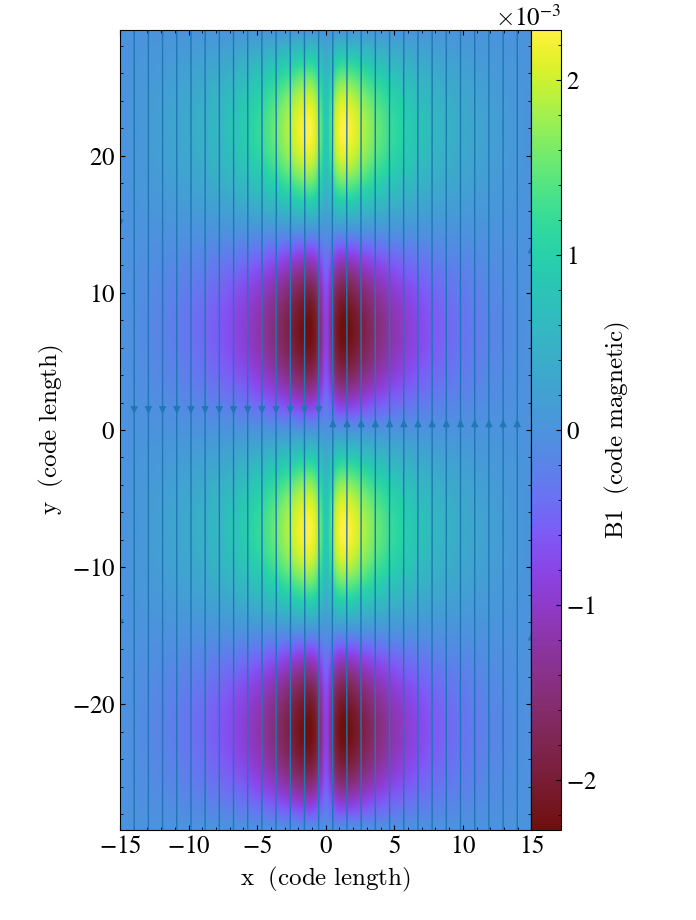

In [2]:
field = ('amrvac', 'b1')
ds = yt.load('./amrvac/0000.dat', unit_system='code')
slc = yt.SlicePlot(ds, 'z', field)
slc.set_log(field, False)
slc.annotate_streamlines(("amrvac", "b1"), ("amrvac", "b2"))
slc

yt : [INFO     ] 2025-11-18 09:52:16,869 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-11-18 09:52:16,870 Parameters: domain_dimensions         = [ 512 1024    1]
yt : [INFO     ] 2025-11-18 09:52:16,871 Parameters: domain_left_edge          = [-15.         -29.16396276   0.        ]
yt : [INFO     ] 2025-11-18 09:52:16,871 Parameters: domain_right_edge         = [15.         29.16396276  1.        ]
yt : [INFO     ] 2025-11-18 09:52:16,872 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-11-18 09:52:16,958 Using full MHD energy for thermal pressure.
yt : [INFO     ] 2025-11-18 09:52:17,160 xlim = -15.000000 15.000000
yt : [INFO     ] 2025-11-18 09:52:17,161 ylim = -29.163963 29.163963
yt : [INFO     ] 2025-11-18 09:52:17,162 xlim = -15.000000 15.000000
yt : [INFO     ] 2025-11-18 09:52:17,163 ylim = -29.163963 29.163963
yt : [INFO     ] 2025-11-18 09:52:17,165 Making a fixed resolution buffer of (('amrvac', 'rho')) 800 by 800



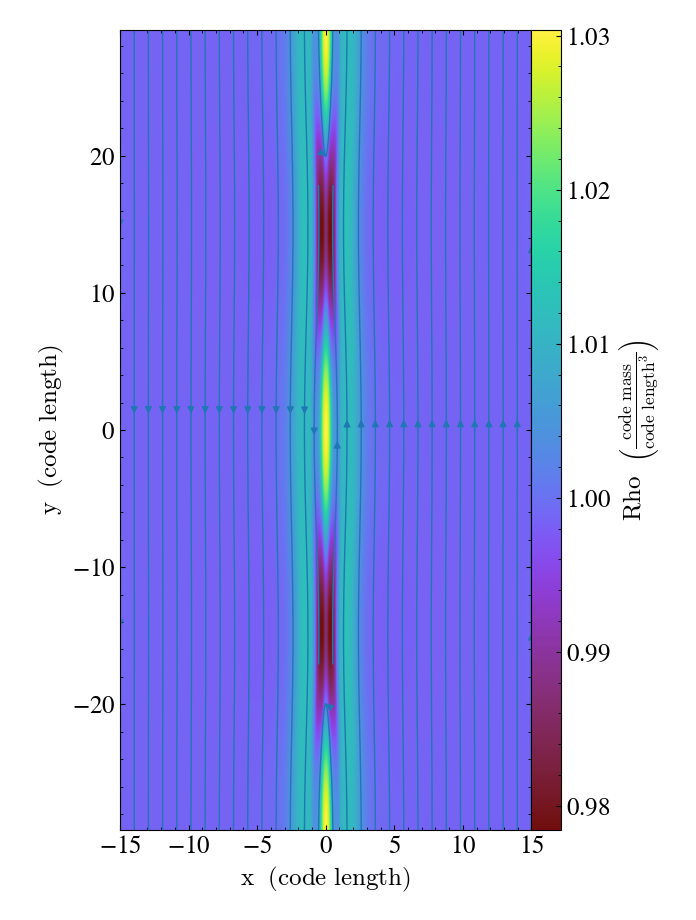

In [3]:
field = ('amrvac', 'rho')
ds = yt.load('./amrvac/0010.dat', unit_system='code')
slc = yt.SlicePlot(ds, 'z', field)
slc.set_log(field, False)
slc.annotate_streamlines(("amrvac", "b1"), ("amrvac", "b2"))
slc